# Basic Classifier

This is the baseline classifier.
It will use 10 of the 16 classes in the dataset. The other 6 will be used later to simulate "rare" species, and will only have a few samples used for training.

## Imports

Below are the imports for libraries used in the classifier.

In [ ]:
# Imports used by both methods

import sys
import numpy as np #math functions
import os #file manipulation
import pandas as pd #table
import matplotlib.pyplot as plt #show results as a graph
import seaborn as sns #histogram for data
import sklearn as sk
from PIL import Image #display image

# Imports used in first method
import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Imports used in second method
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from typing import Tuple
from IPython import display
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from torch.optim.lr_scheduler import ExponentialLR
from torchvision.models import densenet201, DenseNet201_Weights
from torchtnt.framework.fit import fit
from torchtnt.framework.predict import predict
from torchtnt.framework.unit import TrainUnit, EvalUnit, PredictUnit

c:\Users\MHarr\FewShot
c:\Users\MHarr\anaconda3\python39.zip
c:\Users\MHarr\anaconda3\DLLs
c:\Users\MHarr\anaconda3\lib
c:\Users\MHarr\anaconda3

c:\Users\MHarr\anaconda3\lib\site-packages
c:\Users\MHarr\anaconda3\lib\site-packages\win32
c:\Users\MHarr\anaconda3\lib\site-packages\win32\lib
c:\Users\MHarr\anaconda3\lib\site-packages\Pythonwin
c:\Users\MHarr\anaconda3\lib\site-packages\IPython\extensions
C:\Users\MHarr\.ipython


## Retrieve Images

Below is the code to extract the images from the flower folder.
Outputs:
    - The first 5 sample images
    - A histogram displaying the distribution of the images
    - Nine randomly selected images
    

In [2]:
path_to_flowers = "flowers/"

d = {'name':[], 'path':[]}

for label in os.listdir(path_to_flowers):
    path_to_class = os.path.join(path_to_flowers, label)
    for file_name in os.listdir(path_to_class):
        path_to_img = os.path.join(path_to_class, file_name)

        d['name'].append(label)
        d['path'].append(path_to_img)

data = pd.DataFrame(data = d)
data.head()

,name,path
0,astilbe,flowers/astilbe\10091895024_a2ea04cda6_c.jpg
1,astilbe,flowers/astilbe\1033455028_f0c6518ec9_c.jpg
2,astilbe,flowers/astilbe\10373087134_927b53fb9f_c.jpg
3,astilbe,flowers/astilbe\1052212431_4963309d03_c.jpg
4,astilbe,flowers/astilbe\1052219251_d03970e956_c.jpg


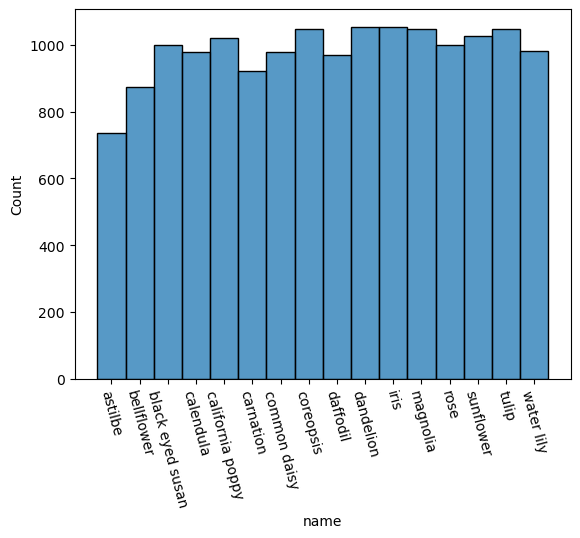

In [3]:
data['name'] = data['name'].str.replace('_',' ')
sns.histplot(data, x = 'name')
plt.xticks(rotation = -75)
None

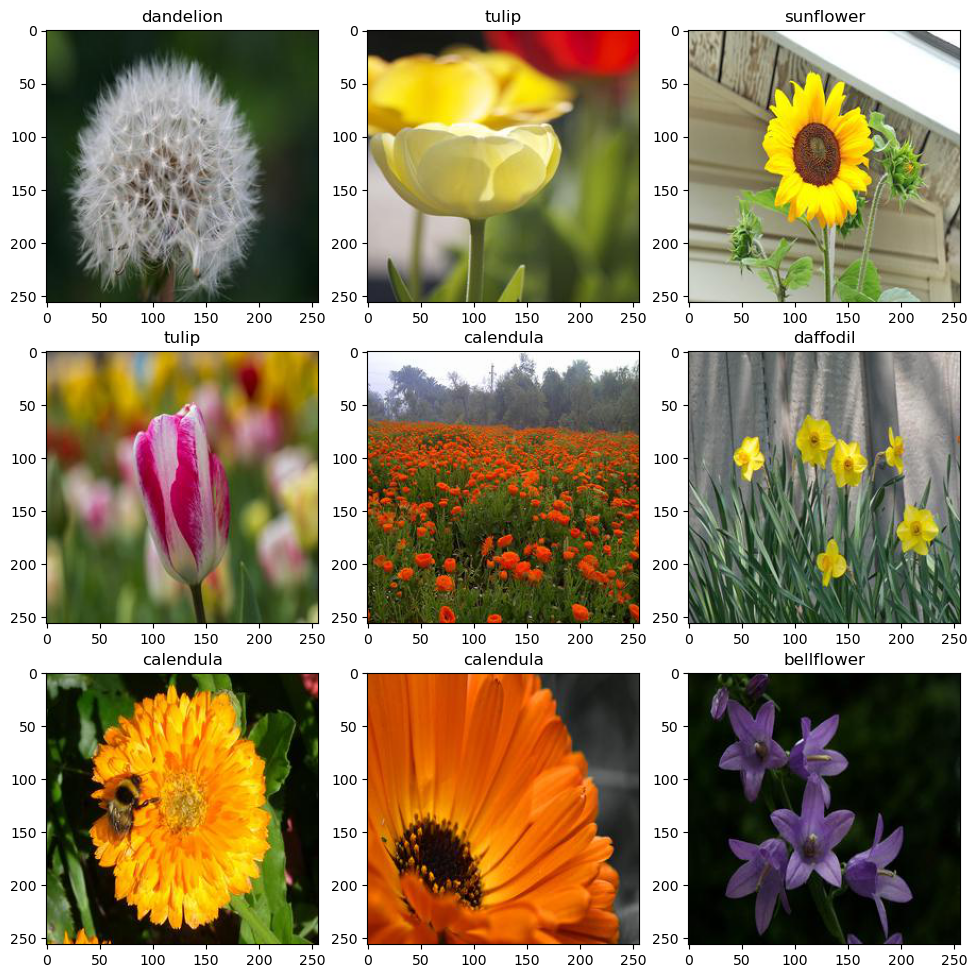

In [4]:
idx = np.random.randint(0, 15740, 9)

axs = plt.subplots(ncols=3, nrows=3, figsize=(10,10))[1].flatten()

for i, ax in zip(idx, axs):
    obj = data.iloc[i]

    img = np.array(Image.open(obj['path']))
    ax.imshow(img)
    ax.set_title(obj['name'])

plt.tight_layout(pad=1.5, w_pad=0.4, h_pad=0.4)
plt.show()

## Data Preparation

Below are two different methods of preparing the images for classification.

In [24]:
selected_labels = ['astilbe', 'bellflower', 'calendula', 'california poppy', 'carnation', 'common daisy', 'coreopsis', 'rose', 'sunflower', 'tulip']

def sample_classes(df, selected_labels, num_samples = 700):

    filtered_df = df[df['name'].isin(selected_labels)]

    sampled_df = pd.DataFrame()
    for label in selected_labels:
        label_df = filtered_df[filtered_df['name'] == label].sample(n = num_samples, replace = True)
        sampled_df = pd.concat([sampled_df, label_df], ignore_index=True)
    
    return sampled_df

sampled_df = sample_classes(data, selected_labels, num_samples=700)
sampled_df['name'].value_counts()

astilbe             700
bellflower          700
calendula           700
california poppy    700
carnation           700
common daisy        700
coreopsis           700
rose                700
sunflower           700
tulip               700
Name: name, dtype: int64

### MODEL METHOD ONE

This version uses the keras.model library to build the CNN used to train the classifier

In [27]:
train_df, temp_df = train_test_split(sampled_df, test_size=0.3, random_state=10)
test_df, valid_df = train_test_split(temp_df, test_size=0.5, random_state=10)

train_datagen = ImageDataGenerator(
    rescale = 1.0/255,
    shear_range = 0.2,
    rotation_range = 0.1,
    zoom_range=0.2,
    horizontal_flip = True,
)

test_datagen = ImageDataGenerator(rescale = 1.0/255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    x_col = 'path',
    y_col = 'label',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    color_mode = 'rgb',
    shuffle = True
)

valid_generator = test_datagen.flow_from_dataframe(
    dataframe = valid_df,
    x_col = 'path',
    y_col = 'label',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    color_mode = 'rgb',
    shuffle = False
)  

test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'path',
    y_col = 'label',
    target_size = (224,224),
    batch_size = 64,
    class_mode = 'categorical',
    color_mode = 'rgb',
    shuffle = False
)  

NameError: name 'ImageDataGenerator' is not defined

In [29]:
model = keras.models.sequential()

model.add(Conv2D(64, (3, 3), input_shape = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS), activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.1))

model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(4, activation = 'softmax'))
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

NameError: name 'keras' is not defined

In [ ]:
weight_path = 'cnn_weights.best.weights.h5'

checkpoint = ModelCheckpoint(weight_path, monitor='val_accuracy', verbose = 1, save_best_only = True, mode = 'max', save_weights_only=True)

early = EarlyStopping(monitor = 'val_accuracy',
                      mode = 'max',
                      patience=4)

callbacks_list = [checkpoint, early]

In [ ]:
epoch_num = 20
history = model.fit(train_generator, epochs=epoch_num, validation_data = (valid_generator), callbacks = callbacks_list)

In [ ]:
model.load_weights(weight_path)

In [ ]:
evaluation_result = model.evaluate(test_generator)

print("METHOD 1 LOSS: ", evaluation_result[0])
print("METHOD 1 ACCURACY: ", evaluation_result[1])

In [ ]:
y_pred = model.predict(test_generator)

y_pred_classes = np.agrmax(y_pred, axis=1)
y_test_classes = test_generator.classes

confusion_matrix = confusion_matrix(y_test_classes, y_pred_classes)

sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc = 'upper left')

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc = 'upper left')

plt.show()

### MODEL METHOD TWO

This model does stuff

In [ ]:
encoder = LabelEncoder()
data['label'] = encoder.fit_transform(data['name'])

In [ ]:
class FlowerDataset(Dataset):
    def __init__(self, dataframe, mode = 'train'):
        if mode not in ['train', 'testval']:
            raise ValueError(f'Not correct mode value {mode}, available models: train, testval')
        
        self._df = dataframe
        self._mode = mode
        self._len = dataframe.shape[0]

        self.transforms = {'train': v2.compose ([v2.ToPILImage(),
                                                 v2.Resize(size=(64,64)),
                                                 v2.RandomRotation(degrees = (-15,15)),
                                                 v2.RandomHorizontalFlip(p=0.5),
                                                 v2.ToTensor(),
                                                 v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
                                                 
                                                 
                            'testval': v2.compose([v2.ToPILImage(),
                                                   v2.Resize(size=(64,64)),
                                                   v2.ToTensor(),
                                                   v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])}
        
    def __len__(self):
        return self._len
    
    def load_img(self, path):
        return np.array(Image.open(path))
    
    def __getitem__(self, index):
        obj = self.df.iloc[index]

        img = self.load_img(obj['path'])

        x = self._transforms[self._mode](img)
        y = obj['label']

        return x, y

In [1]:
flowers_groups = sampled_df.groupby('name')

train_dataframe = pd.DataFrame()
test_dataframe = pd.DataFrame()

percent_data_to_train = 0.7

for name in flowers_groups.groups.keys():
    group = flowers_groups.get_group(name)
    size = group.shape[0]
    train_size = int(size * percent_data_to_train)

    train_dataframe = pd.concat([train_dataframe, group.iloc[0:train_size]], ignore_index=True)

    test_dataframe = pd.concat([test_dataframe, group.iloc[train_size:size]], ignore_index=True)

NameError: name 'sampled_df' is not defined

In [ ]:
train_dataframe = train_dataframe.sample(frac=1).reset_index(drop=True)
test_dataframe = test_dataframe.sample(frac=1).reset_index(drop=True)

train_dataset = FlowerDataset(train_dataframe, mode='train')
test_dataset = FlowerDataset(test_dataframe, mode='testval')

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [ ]:
Batch = Tuple[torch.tensor, torch.tensor]

class ModelUnit(TrainUnit[Batch], EvalUnit[Batch]):
    def __init__(self, 
                model,
                loss_function,
                optimizer,
                lr_scheduler=None,
                device='cpu',
                save_best_weights=True,
                path_to_save_weights='',
                weights_file_name='bestweights.pth'):
        super().__init__()
        self.model = model
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        
        self.save_best_w = save_best_weights
        self.path_to_save = path_to_save_weights
        self.file_name = weights_file_name
        
        self.loss_train_history = []
        self.accuracy_history = []
        self.loss_train = []
        self.accuracy = []

        self.best_acc = -1
        
    def on_train_start(self, state):
        self.model.to(self.device)
    
    def train_step(self, state, data):
        inputs, labels = data
        
        inputs = inputs.to(self.device)
        labels = labels.to(self.device)
        
        outputs = self.model(inputs)
        loss = self.loss_function(outputs, labels)
        loss.backward()
        
        self.optimizer.step()
        self.optimizer.zero_grad()
        self.loss_train.append(loss.item())

    def on_train_epoch_end(self, state):
        if self.lr_scheduler is not None:
            self.lr_scheduler.step()
        
        mean_loss_per_epoch = np.array(self.loss_train).mean()
        self.loss_train_history.append(mean_loss_per_epoch)
        
        self.loss_train.clear()
    
    def on_eval_epoch_start(self, state):
        print('evaluation')

    def eval_step(self, state, data):
        inputs, labels = data
        
        inputs = inputs.to(self.device)
        labels = labels.to(self.device)
        
        outputs = self.model(inputs)
        
        pred = torch.argmax(outputs, 1)
        acc = torch.sum(pred == labels.data)
        self.accuracy.append(acc.item()/pred.size(0))
        
    def on_eval_epoch_end(self, state):
        eval_accuracy_per_epoch = np.array(self.accuracy).mean()
        
        self.accuracy_history.append(eval_accuracy_per_epoch)
        self.accuracy.clear()

        if self.save_best_w and self.accuracy_history[-1] > self.best_acc:
            path_to_save = os.path.join(self.path_to_save, self.file_name)
            torch.save(self.model.state_dict(), path_to_save)
            self.best_acc = self.accuracy_history[-1]
        
        display.clear_output(wait=True)
        num_epochs = self.train_progress._num_epochs_completed
        print(f"epoch: {num_epochs}")
        
        axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 8))[1].flatten()
        
        size1 = len(self.loss_train_history)
        axs[0].plot(range(size1), self.loss_train_history)
        axs[0].set_xlabel('epoch')
        axs[0].set_ylabel('loss function')

        size2 = len(self.accuracy_history)
        axs[1].plot(range(size2), self.accuracy_history)
        axs[1].set_xlabel('epoch')
        axs[1].set_ylabel('accuracy')
        
        plt.tight_layout(w_pad=0.5, h_pad=0.5)
        plt.show()

In [ ]:
model = densenet201(weights=DenseNet201_Weights)
model.classifier = torch.nn.Linear(in_features=1920, out_features=16, bias=True)

loss_function = CrossEntropyLoss()
optimizer = AdamW(model.parameters())
scheduler = ExponentialLR(optimizer, gamma=0.9)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

param = {'path_to_save_weights': '/kaggle/working/',
        'weights_file_name': 'bestweights.pth'}


unit = ModelUnit(model, loss_function, optimizer, lr_scheduler=scheduler, device=DEVICE, **param)

In [ ]:
fit_param = {'max_epochs': 80,
            'max_eval_steps_per_epoch': 10,
            'evaluate_every_n_epochs': 1}


fit(unit, train_dataloader=train_dataloader, eval_dataloader=test_dataloader, **fit_param)